In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')

In [3]:
from pipeline import portfolio, run
import pandas as pd
import yaml

with open('config.yml', 'r') as file:
    config = yaml.safe_load(file)

START = config['backtest_start']
END = config['backtest_end']

START_EVAL = config['start_eval']
END_EVAL = config['end_eval']

tickers = pd.read_csv('results/universe_selection/final_assets.csv', skiprows = 1, header = None)[0].tolist()

results = portfolio.aggregate_results(tickers, start = START, end = END)
portfolio_df = portfolio.build_portfolio(tickers, results)
portfolio_df = portfolio_df.loc[START_EVAL: END_EVAL]

_, spy_df = run.load_spy(start = START_EVAL, end = END_EVAL)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


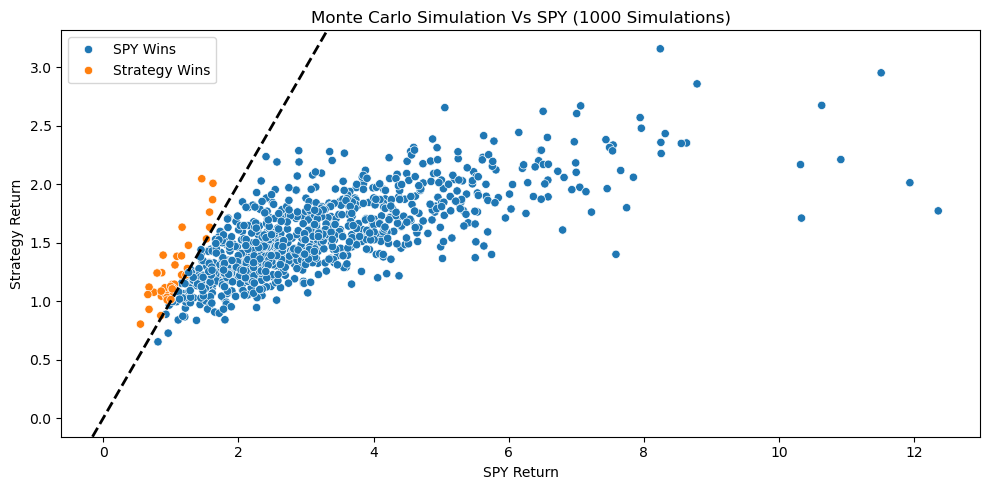

In [4]:
from evaluation import plot
from pipeline import monte_carlo

strat_sim, spy_sim = monte_carlo.run_monte_carlo(portfolio_df, spy_df)
monte_carlo_plot = plot.plot_monte_carlo(strat_sim, spy_sim)

monte_carlo_plot.savefig('results/out_of_sample_portfolio/monte_carlo.png')